In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/UIT/CS114/model 4

/content/drive/MyDrive/UIT/CS114/model 4


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#***EDA***

## annonimized.csv


In [4]:
df=pd.read_csv('/content/drive/MyDrive/UIT/CS114/Wecode/annonimized.csv')
df.head(5)

,"concat('it001',`assignment_id`)","concat('it001',`problem_id`)","concat('it001', username)",is_final,status,pre_score,coefficient,"concat('it001',`language_id`)",created_at,updated_at,judgement
0,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,10-09 08:02:04,10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
1,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,10-09 08:04:41,10-09 08:04:51,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
2,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 08:06:49,10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
3,90ce27571176d87961b565d5ef4b3de33ede04ac,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 08:47:52,10-09 08:48:01,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
4,90ce27571176d87961b565d5ef4b3de33ede04ac,7a6e5ca470ff47c3b5048f240c4738de71010c78,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 09:19:35,10-09 09:19:45,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."


In [5]:
print("\n Kiểm tra dữ liệu")
df.info()


 Kiểm tra dữ liệu
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295198 entries, 0 to 295197
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   concat('it001',`assignment_id`)  295198 non-null  object
 1   concat('it001',`problem_id`)     295198 non-null  object
 2   concat('it001', username)        295198 non-null  object
 3   is_final                         295198 non-null  int64 
 4   status                           295198 non-null  object
 5   pre_score                        295198 non-null  int64 
 6   coefficient                      295198 non-null  int64 
 7   concat('it001',`language_id`)    295198 non-null  object
 8   created_at                       295198 non-null  object
 9   updated_at                       295198 non-null  object
 10  judgement                        295198 non-null  object
dtypes: int64(3), object(8)
memory usage: 24.8+ MB


In [6]:
print(df.nunique())

concat('it001',`assignment_id`)       203
concat('it001',`problem_id`)          469
concat('it001', username)            1489
is_final                                2
status                                  4
pre_score                             631
coefficient                             4
concat('it001',`language_id`)           6
created_at                         284530
updated_at                         242976
judgement                           58406
dtype: int64


In [7]:
df = df.rename(columns={
    "concat('it001', username)": "hash",
    "concat('it001',`assignment_id`)": "assignment_id",
    "concat('it001',`problem_id`)": "problem_id",
    "pre_score": "score",
    "coefficient": "late_coef",
    "created_at": "submit_time",
    "updated_at": "judge_time",
    "concat('it001',`language_id`)": "lang_id",
    "judgement": "judgement_json"
})

In [8]:
df.head(5)

,assignment_id,problem_id,hash,is_final,status,score,late_coef,lang_id,submit_time,judge_time,judgement_json
0,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,10-09 08:02:04,10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
1,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,10-09 08:04:41,10-09 08:04:51,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
2,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 08:06:49,10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
3,90ce27571176d87961b565d5ef4b3de33ede04ac,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 08:47:52,10-09 08:48:01,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
4,90ce27571176d87961b565d5ef4b3de33ede04ac,7a6e5ca470ff47c3b5048f240c4738de71010c78,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 09:19:35,10-09 09:19:45,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."


In [9]:
# Chuyển cột thời gian sang kiểu datetime
# Vì dữ liệu không có năm, ta giả định năm 2024 để xử lý
df['submit_time'] = pd.to_datetime('2024-' + df['submit_time'], errors='coerce')
df['judge_time'] = pd.to_datetime('2024-' + df['judge_time'], errors='coerce')

In [10]:
df['status'].unique()

array(['SCORE', 'Compilation Error', 'pending', 'Syntax Error'],
      dtype=object)

In [11]:
custom_map = {
    'SCORE': 3,               # tốt nhất
    'pending': 2,
    'Syntax Error': 1,
    'Compilation Error': 0    # tệ nhất
}

df['status'] = df['status'].map(custom_map)

In [12]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
for col in ['assignment_id', 'problem_id', 'lang_id']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [13]:
df_encoded.head(5)

,assignment_id,problem_id,hash,is_final,status,score,late_coef,lang_id,submit_time,judge_time,judgement_json
0,116,208,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,3,0,100,1,2024-10-09 08:02:04,2024-10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
1,116,208,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,3,0,100,1,2024-10-09 08:04:41,2024-10-09 08:04:51,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
2,116,208,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,3,10000,100,1,2024-10-09 08:06:49,2024-10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
3,116,335,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,3,10000,100,1,2024-10-09 08:47:52,2024-10-09 08:48:01,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
4,116,212,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,3,10000,100,1,2024-10-09 09:19:35,2024-10-09 09:19:45,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."


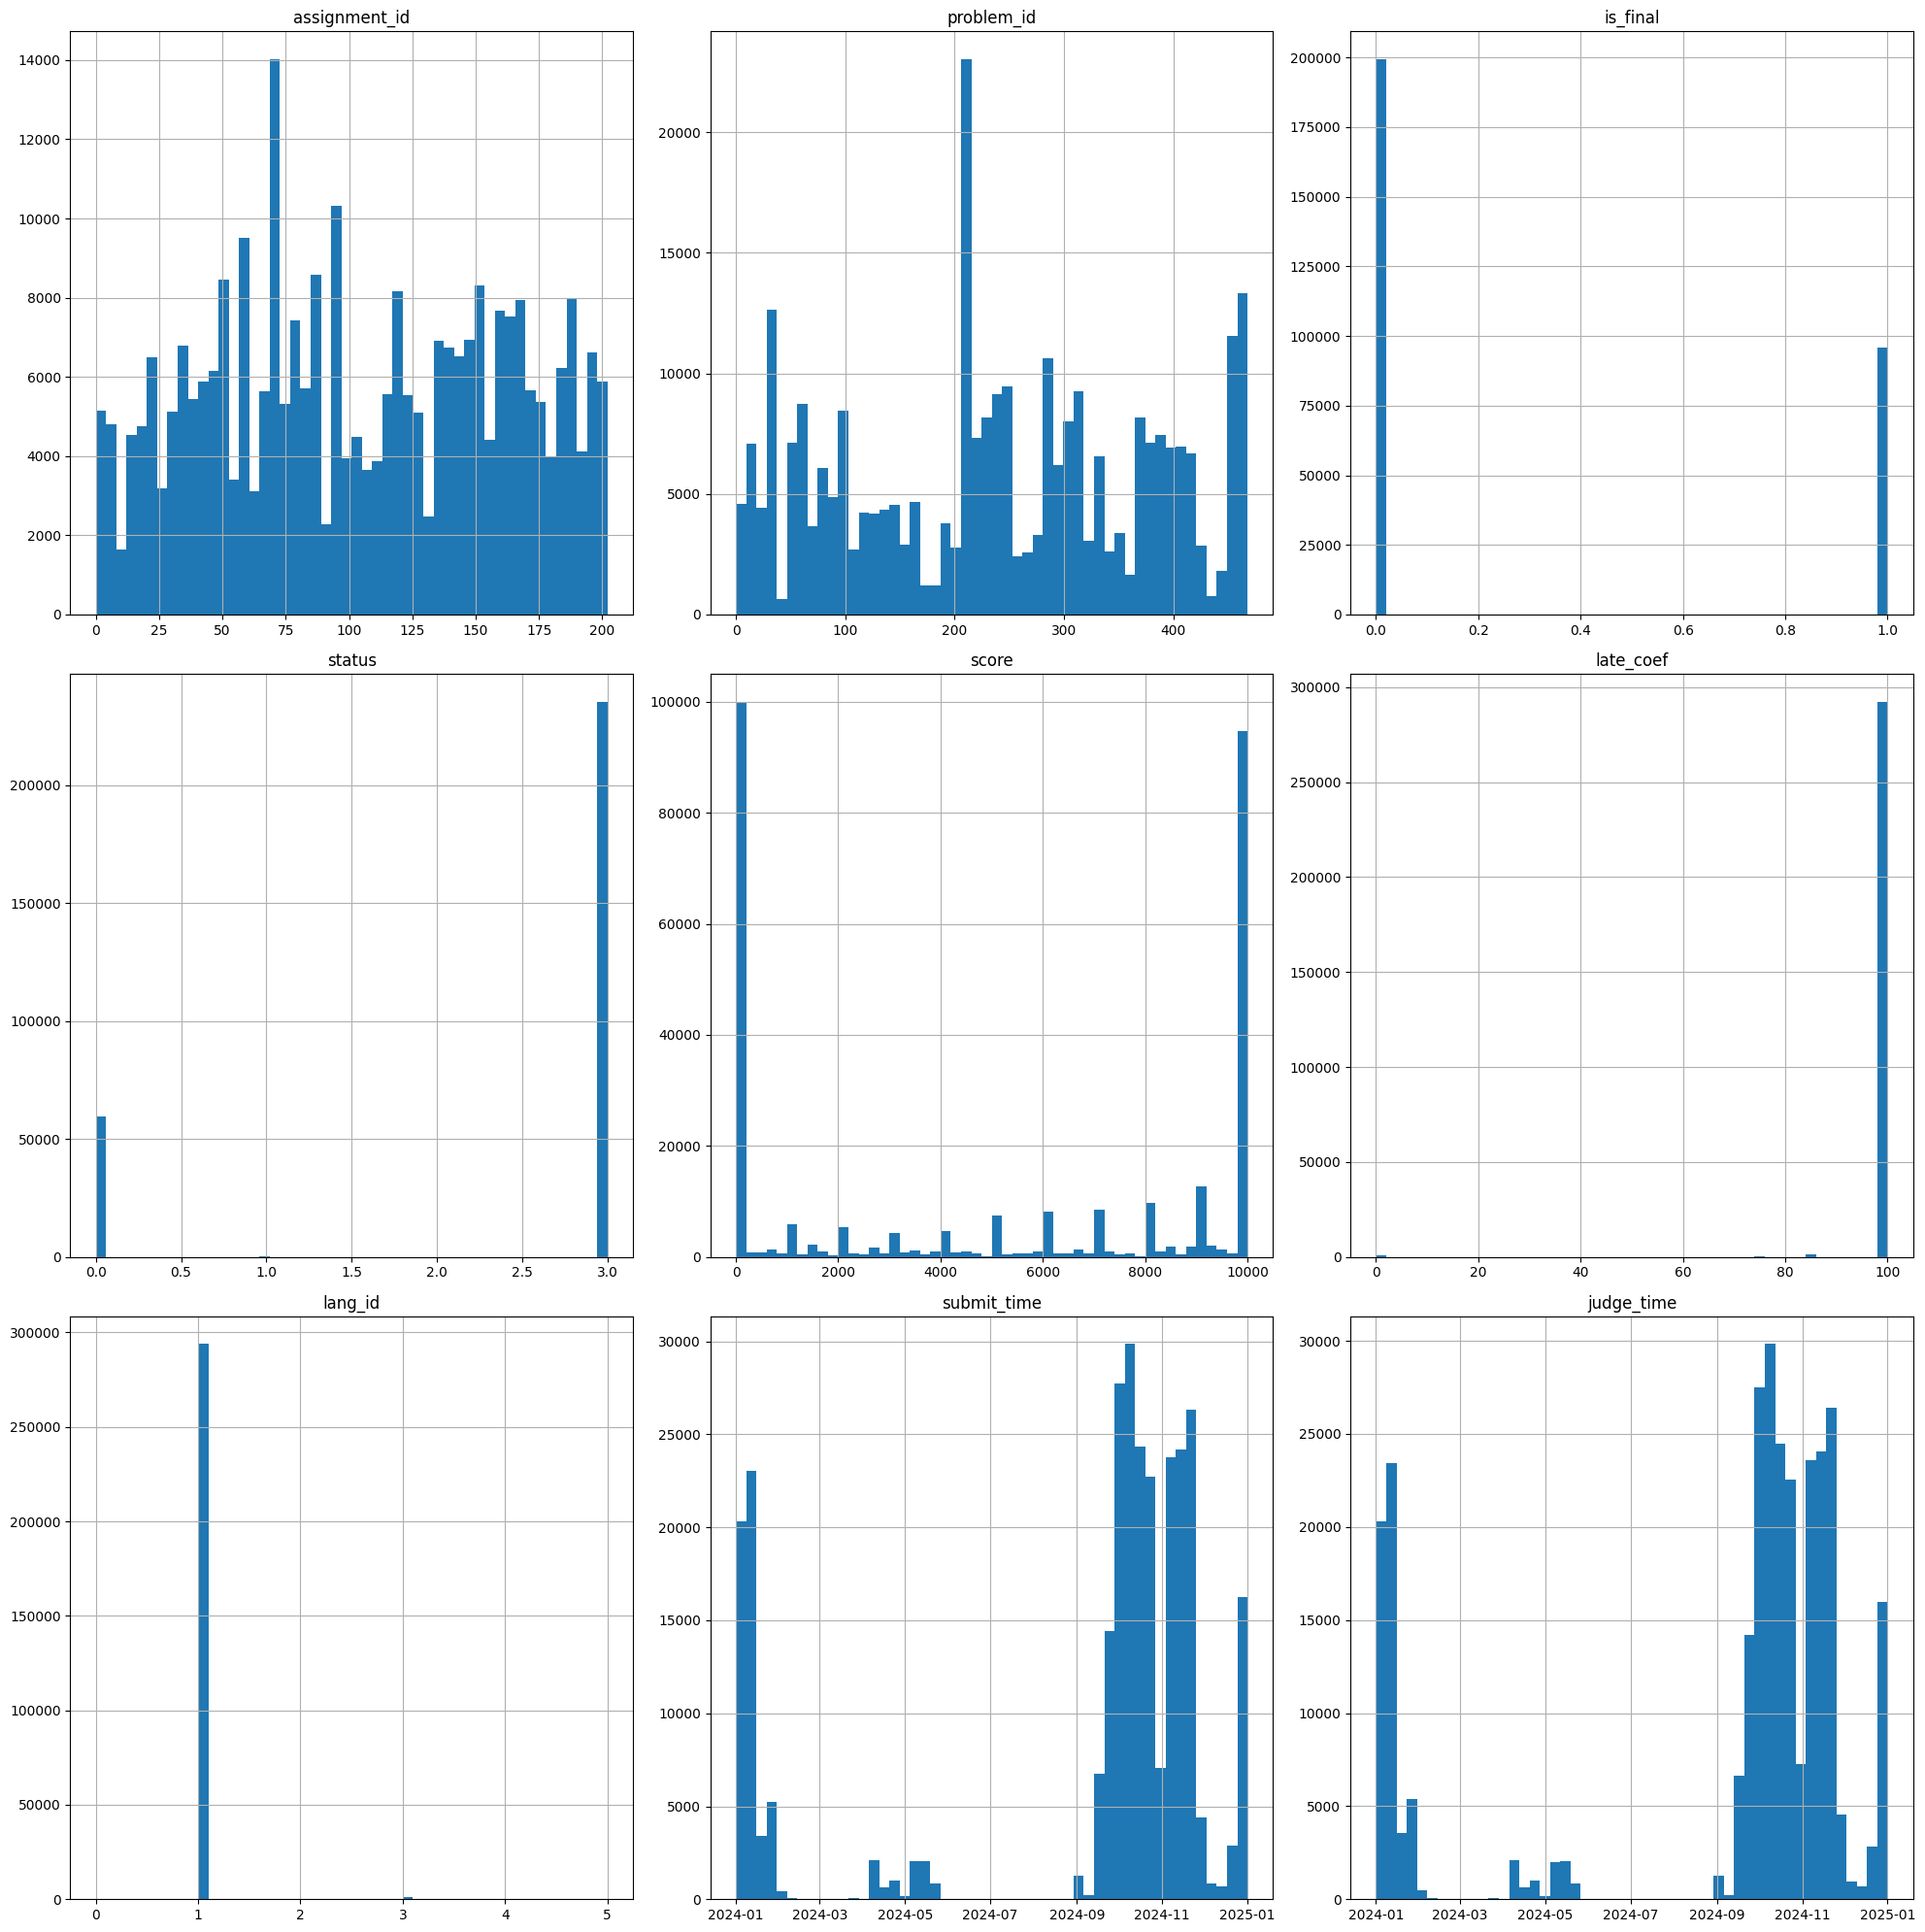

In [14]:
df_encoded.hist(figsize=(20, 20), bins=50)
plt.tight_layout()
plt.show()

In [15]:
df = df_encoded.drop(columns=['judgement_json'])

In [16]:
df.head(5)

,assignment_id,problem_id,hash,is_final,status,score,late_coef,lang_id,submit_time,judge_time
0,116,208,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,3,0,100,1,2024-10-09 08:02:04,2024-10-09 08:06:58
1,116,208,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,3,0,100,1,2024-10-09 08:04:41,2024-10-09 08:04:51
2,116,208,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,3,10000,100,1,2024-10-09 08:06:49,2024-10-09 08:06:58
3,116,335,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,3,10000,100,1,2024-10-09 08:47:52,2024-10-09 08:48:01
4,116,212,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,3,10000,100,1,2024-10-09 09:19:35,2024-10-09 09:19:45


## TH.CSV


In [17]:
df_th =  pd.read_csv('/content/drive/MyDrive/UIT/CS114/Wecode/th-public.csv')

In [18]:
df_th.head(5)

,hash,TH
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,5
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,8.5
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7
3,013de369c439ab0ead8aa7da64423aa395a8be39,10
4,014c59c6433fd764a0b08de6ffeb757eaf60aa73,6


In [19]:
df_th.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   hash    761 non-null    object
 1   TH      755 non-null    object
dtypes: object(2)
memory usage: 12.0+ KB


In [20]:
#chuyển TH thành dạng float
df_th['TH'] = pd.to_numeric(df_th['TH'], errors='coerce')

In [21]:
#xử lý null của cột TH
print(df_th.isna().sum())
nan_rows = df_th[df_th.isna().any(axis=1)]
print(nan_rows)

hash    0
TH      8
dtype: int64
                                         hash  TH
38   06024da8147b5cf6105beb4c403f67cf1ff0aea1 NaN
83   0d815307d5307124d148bbebfb41497230c4bd15 NaN
91   0eb93817d6eb3d5bd3e44dbc75971eea193b924f NaN
195  209d7c77e7a150b6990a3372f7cb24da0c0e7e07 NaN
210  2383a9a33025aa8759fee9a890f6420df0fc8b47 NaN
244  2855b4b4d03c37c94117e615a25e0e321ec8d77a NaN
515  59b2a9ae92876d8ce54309fe82bb92d7cffbc794 NaN
655  7186e8a3fb8c0322eee7e354ed8f1669885f6774 NaN


In [22]:
# Xóa những sinh viên có điểm TH là NaN
df_th = df_th.dropna(subset=['TH'])
# Kiểm tra còn NaN không
print(df_th.isna().sum())
df_th.info()


hash    0
TH      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 753 entries, 0 to 760
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   hash    753 non-null    object 
 1   TH      753 non-null    float64
dtypes: float64(1), object(1)
memory usage: 17.6+ KB


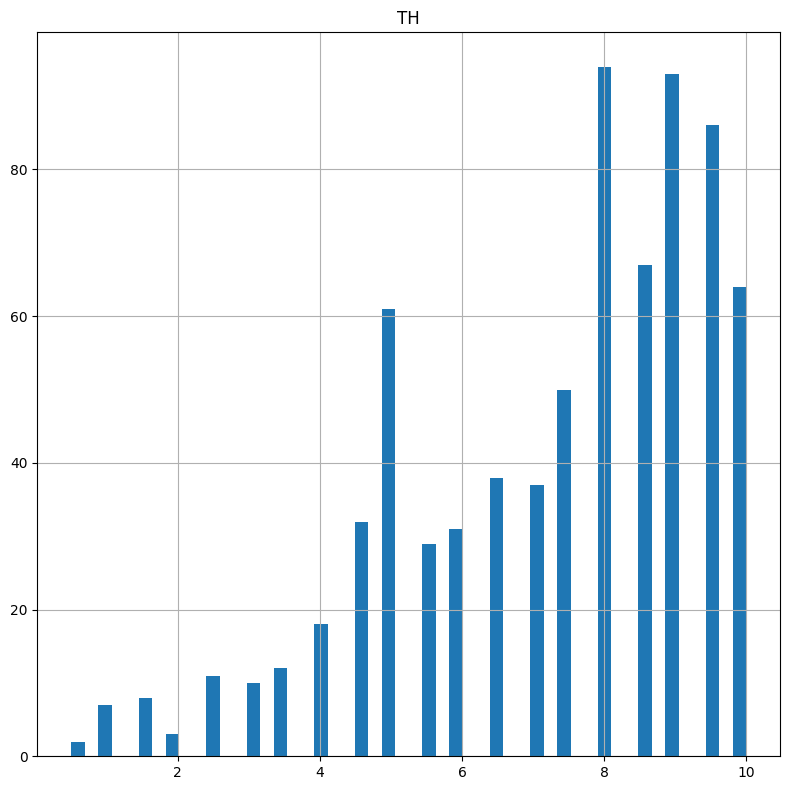

In [23]:
df_th.hist(figsize=(8, 8), bins=50)
plt.tight_layout()
plt.show()

# Trích xuất đặc trưng

In [24]:
# Tạo df_copy chỉ chứa sinh viên có mặt trong df_th
df_copy = df[df['hash'].isin(df_th['hash'].unique())].copy()

In [25]:
df_copy.head(5)

,assignment_id,problem_id,hash,is_final,status,score,late_coef,lang_id,submit_time,judge_time
458,116,208,0bd2037bf68a97753e5e67ab55dac026a649f279,0,0,0,100,1,2024-10-11 16:15:32,2024-10-11 16:16:36
459,116,208,0bd2037bf68a97753e5e67ab55dac026a649f279,0,0,0,100,1,2024-10-11 16:16:30,2024-10-11 16:16:31
460,116,208,0bd2037bf68a97753e5e67ab55dac026a649f279,0,0,0,100,1,2024-10-11 16:23:46,2024-10-11 16:43:17
461,116,208,0bd2037bf68a97753e5e67ab55dac026a649f279,0,0,0,100,1,2024-10-11 16:25:55,2024-10-11 16:25:56
462,116,208,0bd2037bf68a97753e5e67ab55dac026a649f279,0,0,0,100,1,2024-10-11 16:26:24,2024-10-11 16:26:25


In [26]:
df_train = pd.DataFrame()

In [27]:
df_train = df_th.copy()
# 3. Tính tổng số bài nộp từ df
submission_counts = df_copy.groupby('hash').size().reset_index(name='submit_count')


# 4. Gộp submit_count vào df_train
df_train = df_train.merge(submission_counts, on='hash', how='left')

# 5. Điền 0 nếu chưa nộp bài
df_train['submit_count'] = df_train['submit_count'].fillna(0).astype(int)


In [28]:
df_train.info()
df_train.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hash          753 non-null    object 
 1   TH            753 non-null    float64
 2   submit_count  753 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 17.8+ KB


,hash,TH,submit_count
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,5.0,147
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,8.5,259
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7.0,195
3,013de369c439ab0ead8aa7da64423aa395a8be39,10.0,107
4,014c59c6433fd764a0b08de6ffeb757eaf60aa73,6.0,199


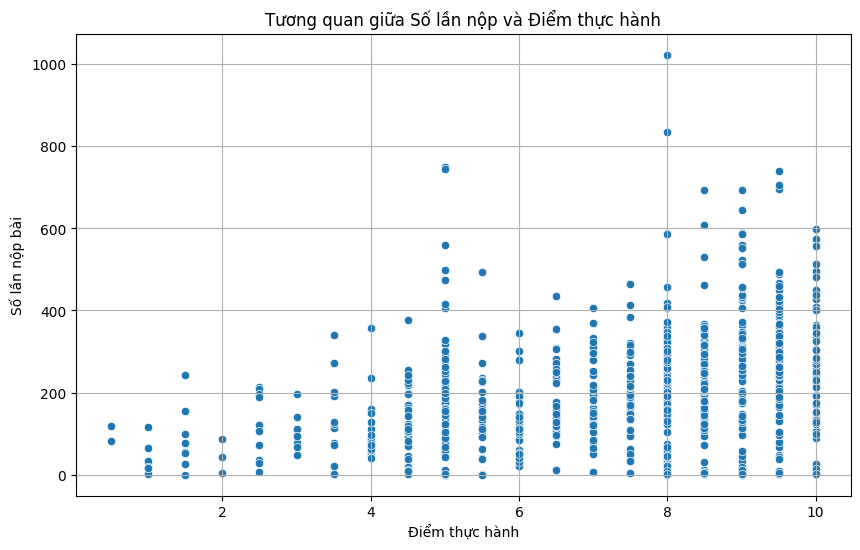

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ scatter plot thể hiện tương quan giữa số lần nộp và điểm thực hành
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, y='submit_count', x='TH')

plt.title('Tương quan giữa Số lần nộp và Điểm thực hành')
plt.ylabel('Số lần nộp bài')
plt.xlabel('Điểm thực hành')
plt.grid(True)
plt.show()


Xu hướng tăng rõ rệt: Nhìn chung, sinh viên có điểm thực hành cao hơn thường nộp nhiều bài hơn.

Những sinh viên đạt điểm từ 8 → 10 có số lượng nộp thường vượt xa các điểm thấp hơn.

In [30]:
# 1. Lấy các dòng is_final == 1 từ toàn bộ df
df_final = df_copy[df_copy['is_final'] == 1]

# 2. Tính tổng số bài is_final theo sinh viên
final_submit_count = df_final.groupby('hash').size().rename('final_submit_count').reset_index()

# 3. Gộp vào df_train (đã tạo từ all_hash.merge(df_th, how='left'))
df_train = df_train.merge(final_submit_count, on='hash', how='left')

# 4. Điền 0 nếu sinh viên chưa có bài is_final
df_train['final_submit_count'] = df_train['final_submit_count'].fillna(0).astype(int)


In [31]:
df_train.head(5)

,hash,TH,submit_count,final_submit_count
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,5.0,147,46
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,8.5,259,78
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7.0,195,67
3,013de369c439ab0ead8aa7da64423aa395a8be39,10.0,107,66
4,014c59c6433fd764a0b08de6ffeb757eaf60aa73,6.0,199,90


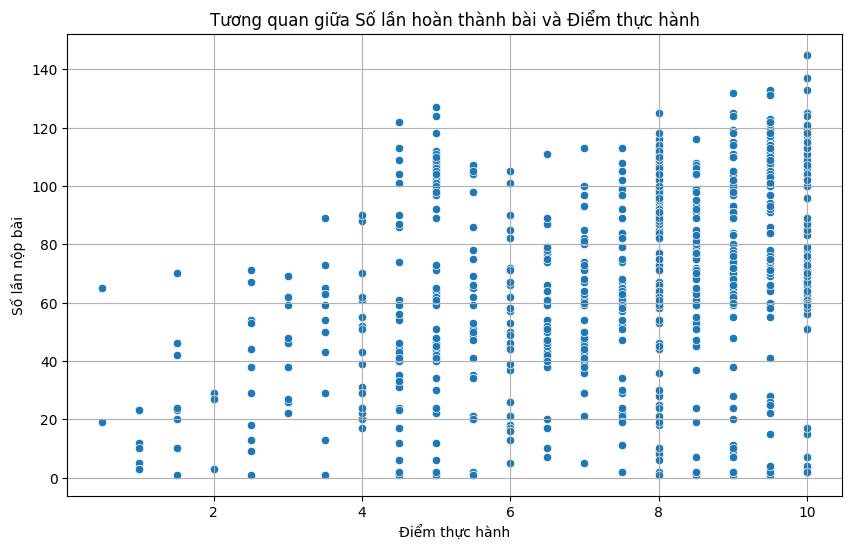

In [32]:
# Vẽ scatter plot thể hiện tương quan giữa số hoàn thành bài và điểm thực hành
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, y='final_submit_count', x='TH')

plt.title('Tương quan giữa Số lần hoàn thành bài và Điểm thực hành')
plt.ylabel('Số lần nộp bài')
plt.xlabel('Điểm thực hành')
plt.grid(True)
plt.show()

In [33]:

# 2. Lọc những dòng có is_final == 1
df_final = df_copy[df_copy['is_final'] == 1]
# 3. Tính điểm trung bình của các bài is_final
avg_final_score = df_final.groupby('hash')['score'].mean().rename('avg_final_score')
# 4. Gộp vào df_train
df_train = df_train.merge(avg_final_score, on='hash', how='left')
# 5. Nếu sinh viên không có bài is_final, điền giá trị 0
df_train['avg_final_score'] = df_train['avg_final_score'].fillna(0)


In [34]:
df_train.head(5)

,hash,TH,submit_count,final_submit_count,avg_final_score
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,5.0,147,46,10000.000000
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,8.5,259,78,9647.423077
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7.0,195,67,9391.253731
3,013de369c439ab0ead8aa7da64423aa395a8be39,10.0,107,66,9176.151515
4,014c59c6433fd764a0b08de6ffeb757eaf60aa73,6.0,199,90,8844.444444


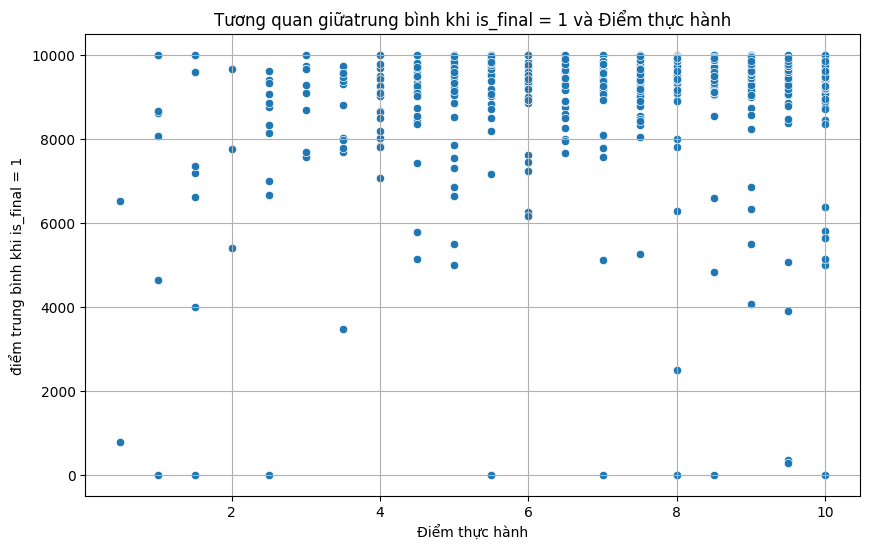

In [35]:
# Vẽ scatter plot thể hiện tương quan giữa số hoàn thành bài và điểm thực hành
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, y='avg_final_score', x='TH')

plt.title('Tương quan giữatrung bình khi is_final = 1 và Điểm thực hành')
plt.ylabel('điểm trung bình khi is_final = 1')
plt.xlabel('Điểm thực hành')
plt.grid(True)
plt.show()

In [36]:
# Đếm số lượng status đã encode (giá trị từ 0 đến 3)
status_counts = df_copy.groupby(['hash', 'status']).size().unstack(fill_value=0)

# Đặt tên cột lại cho rõ ràng
status_counts.columns = [f'count_status_{int(col)}' for col in status_counts.columns]

# Gộp vào df_train
df_train = df_train.merge(status_counts, on='hash', how='left')

# Ép kiểu về int
df_train[status_counts.columns] = df_train[status_counts.columns].astype(int)
df_train.head(5)

,hash,TH,submit_count,final_submit_count,avg_final_score,count_status_0,count_status_1,count_status_2,count_status_3
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,5.0,147,46,10000.000000,28,0,0,119
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,8.5,259,78,9647.423077,50,0,0,209
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7.0,195,67,9391.253731,20,0,0,175
3,013de369c439ab0ead8aa7da64423aa395a8be39,10.0,107,66,9176.151515,13,0,0,94
4,014c59c6433fd764a0b08de6ffeb757eaf60aa73,6.0,199,90,8844.444444,45,0,0,154


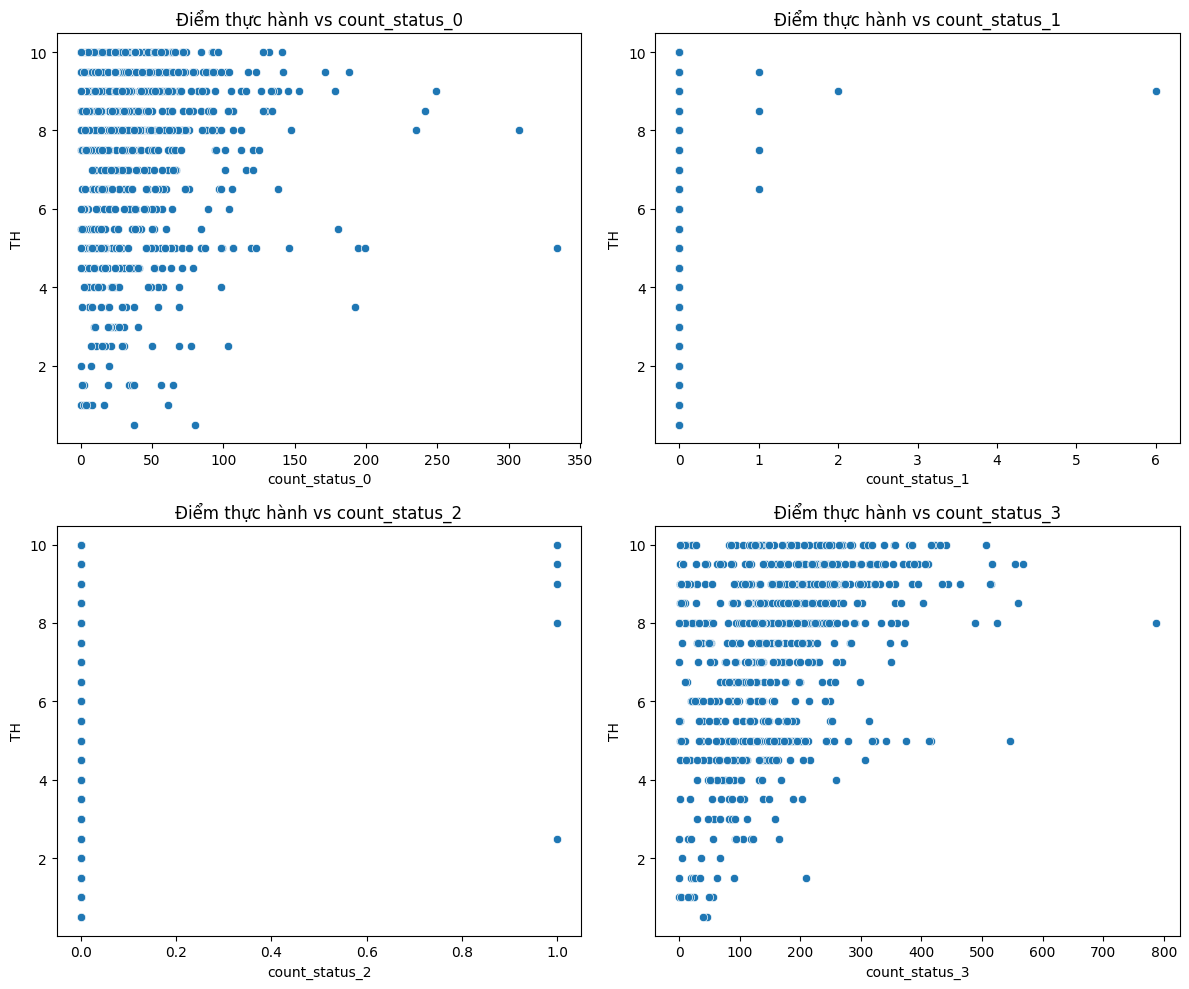

In [37]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
status_cols = ['count_status_0', 'count_status_1', 'count_status_2', 'count_status_3']

for i, col in enumerate(status_cols):
    sns.scatterplot(data=df_train, x=col, y='TH', ax=axs[i // 2][i % 2])
    axs[i // 2][i % 2].set_title(f'Điểm thực hành vs {col}')
    axs[i // 2][i % 2].set_xlabel(col)
    axs[i // 2][i % 2].set_ylabel('TH')

plt.tight_layout()
plt.show()


In [38]:
# 2. Đếm số lượng lang_id khác nhau theo từng sinh viên
lang_count = df_copy.groupby('hash')['lang_id'].nunique().rename('lang_count')
# 3. Gộp vào df_train
df_train = df_train.merge(lang_count, on='hash', how='left')
# 4. Điền 0 nếu sinh viên chưa nộp bài nào (hiếm)
df_train['lang_count'] = df_train['lang_count'].fillna(0).astype(int)
df_train.head(5)

,hash,TH,submit_count,final_submit_count,avg_final_score,count_status_0,count_status_1,count_status_2,count_status_3,lang_count
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,5.0,147,46,10000.000000,28,0,0,119,1
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,8.5,259,78,9647.423077,50,0,0,209,1
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7.0,195,67,9391.253731,20,0,0,175,1
3,013de369c439ab0ead8aa7da64423aa395a8be39,10.0,107,66,9176.151515,13,0,0,94,1
4,014c59c6433fd764a0b08de6ffeb757eaf60aa73,6.0,199,90,8844.444444,45,0,0,154,1


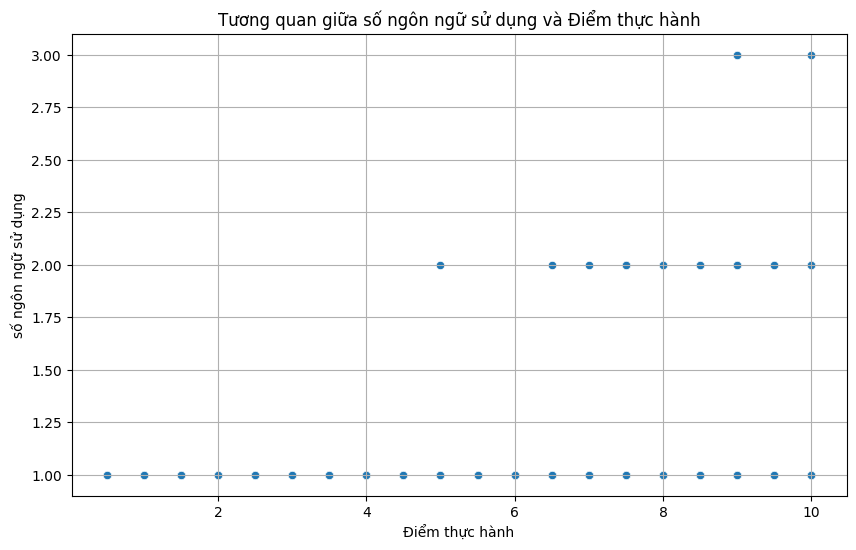

In [39]:
# Vẽ scatter plot thể hiện tương quan giữa số ngôn ngữ và điểm thực hành
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, y='lang_count', x='TH')

plt.title('Tương quan giữa số ngôn ngữ sử dụng và Điểm thực hành')
plt.ylabel('số ngôn ngữ sử dụng')
plt.xlabel('Điểm thực hành')
plt.grid(True)
plt.show()

In [40]:
# 2. Tính trung bình late_coef
avg_late_coef = df_copy.groupby('hash')['late_coef'].mean().rename('avg_late_coef')

# 3. Gộp vào df_train
df_train = df_train.merge(avg_late_coef, on='hash', how='left')

# 4. Điền 0 nếu không có bài nào
df_train['avg_late_coef'] = df_train['avg_late_coef'].fillna(0)
df_train.head(5)

,hash,TH,submit_count,final_submit_count,avg_final_score,count_status_0,count_status_1,count_status_2,count_status_3,lang_count,avg_late_coef
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,5.0,147,46,10000.000000,28,0,0,119,1,100.000000
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,8.5,259,78,9647.423077,50,0,0,209,1,100.000000
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7.0,195,67,9391.253731,20,0,0,175,1,100.000000
3,013de369c439ab0ead8aa7da64423aa395a8be39,10.0,107,66,9176.151515,13,0,0,94,1,97.196262
4,014c59c6433fd764a0b08de6ffeb757eaf60aa73,6.0,199,90,8844.444444,45,0,0,154,1,100.000000


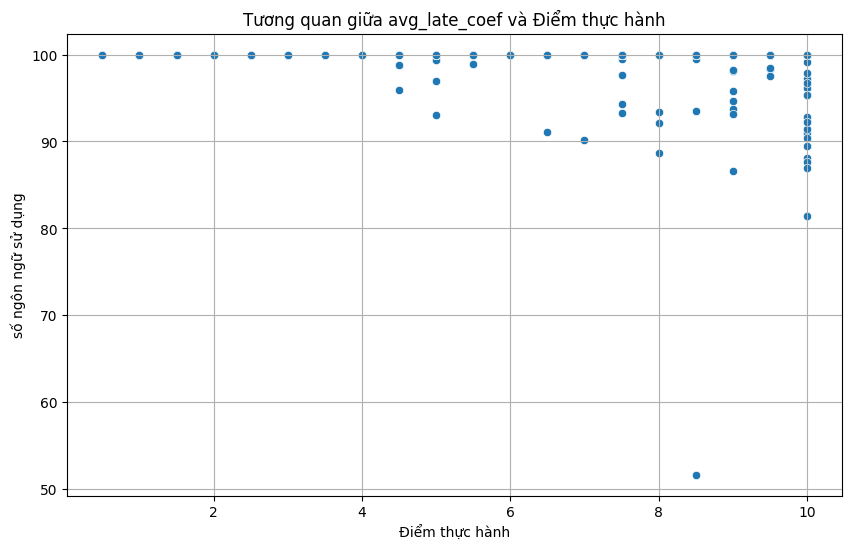

In [41]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, y='avg_late_coef', x='TH')

plt.title('Tương quan giữa avg_late_coef và Điểm thực hành')
plt.ylabel('số ngôn ngữ sử dụng')
plt.xlabel('Điểm thực hành')
plt.grid(True)
plt.show()

In [42]:
# 2. Đếm số lần nộp cho mỗi bài
submit_counts = df_copy.groupby(['hash', 'problem_id']).size().reset_index(name='submission_count')

# 3. Tính trung bình số lần nộp lại mỗi bài của mỗi sinh viên
avg_resubmit = submit_counts.groupby('hash')['submission_count'].mean().rename('avg_submission_per_problem')

# 4. Gộp vào df_train
df_train = df_train.merge(avg_resubmit, on='hash', how='left')

# 5. Điền 0 nếu sinh viên chưa nộp bài nào
df_train['avg_submission_per_problem'] = df_train['avg_submission_per_problem'].fillna(0)


In [43]:
df_train.head(5)

,hash,TH,submit_count,final_submit_count,avg_final_score,count_status_0,count_status_1,count_status_2,count_status_3,lang_count,avg_late_coef,avg_submission_per_problem
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,5.0,147,46,10000.000000,28,0,0,119,1,100.000000,3.195652
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,8.5,259,78,9647.423077,50,0,0,209,1,100.000000,3.320513
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7.0,195,67,9391.253731,20,0,0,175,1,100.000000,2.954545
3,013de369c439ab0ead8aa7da64423aa395a8be39,10.0,107,66,9176.151515,13,0,0,94,1,97.196262,2.057692
4,014c59c6433fd764a0b08de6ffeb757eaf60aa73,6.0,199,90,8844.444444,45,0,0,154,1,100.000000,2.211111


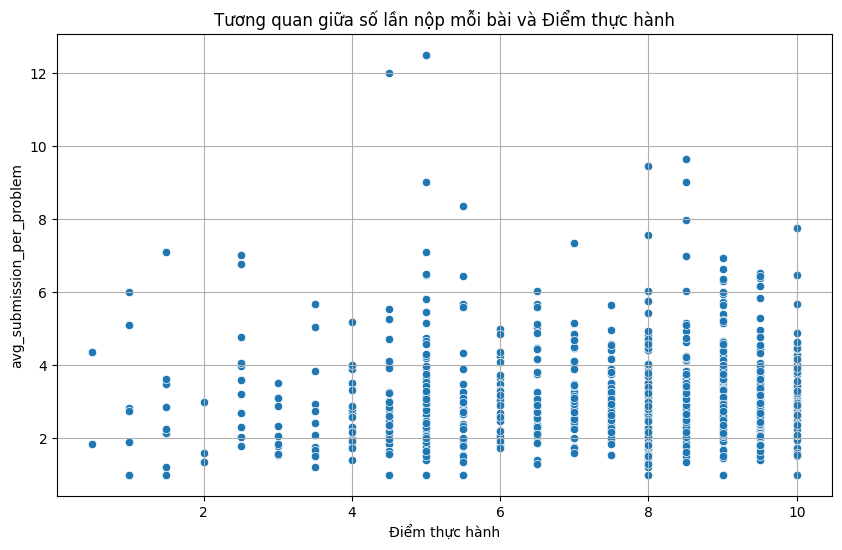

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, y='avg_submission_per_problem', x='TH')

plt.title('Tương quan giữa số lần nộp mỗi bài và Điểm thực hành')
plt.ylabel('avg_submission_per_problem')
plt.xlabel('Điểm thực hành')
plt.grid(True)
plt.show()

In [45]:
# Lấy thời gian nộp sớm nhất và chấm muộn nhất cho từng bài
earliest = df_copy[['hash', 'problem_id', 'submit_time']].groupby(['hash', 'problem_id'], as_index=False).min()
latest = df_copy[['hash', 'problem_id', 'judge_time']].groupby(['hash', 'problem_id'], as_index=False).max()

# Tính chênh lệch thời gian làm bài (giây)
time_diff = earliest.merge(latest, on=['hash', 'problem_id'])
time_diff['time'] = (time_diff['judge_time'] - time_diff['submit_time']).dt.total_seconds()

# Trung bình thời gian làm bài theo từng sinh viên
average_time = time_diff.groupby('hash', as_index=False)['time'].mean()
average_time.rename(columns={'time': 'average_time'}, inplace=True)

# Gộp vào df_train
df_train = df_train.merge(average_time, on='hash', how='left')
df_train['average_time'] = df_train['average_time'].fillna(0)
df_train['average_time'] = df_train['average_time'].astype(int)
df_train.head(15)

,hash,TH,submit_count,final_submit_count,avg_final_score,count_status_0,count_status_1,count_status_2,count_status_3,lang_count,avg_late_coef,avg_submission_per_problem,average_time
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,5.0,147,46,10000.000000,28,0,0,119,1,100.000000,3.195652,34633
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,8.5,259,78,9647.423077,50,0,0,209,1,100.000000,3.320513,878577
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7.0,195,67,9391.253731,20,0,0,175,1,100.000000,2.954545,366931
3,013de369c439ab0ead8aa7da64423aa395a8be39,10.0,107,66,9176.151515,13,0,0,94,1,97.196262,2.057692,220904
4,014c59c6433fd764a0b08de6ffeb757eaf60aa73,6.0,199,90,8844.444444,45,0,0,154,1,100.000000,2.211111,133854
5,0155f91fe242fe55e1af631b0f0afbe9938b185c,7.5,179,60,9533.333333,41,0,0,138,1,99.441341,3.891304,258117
6,016f87a7bd87f233a8633fba8a1ca7ef5c3c63c1,8.0,364,77,9258.649351,58,0,0,306,1,100.000000,4.666667,476670
7,017ec1bbad0d598e5a86ac3bd595b870b6456e61,8.5,218,91,9682.879121,26,0,0,192,1,100.000000,2.395604,2811
8,01ad03ec301749c033155fc17e657cc767d447c8,7.5,271,74,9434.405405,53,0,0,218,1,100.000000,3.763889,532853
9,020ef1c31cb4751bbfa1a88fba782db3c402e2fa,5.5,175,75,9533.333333,26,0,0,149,1,100.000000,2.822581,193809


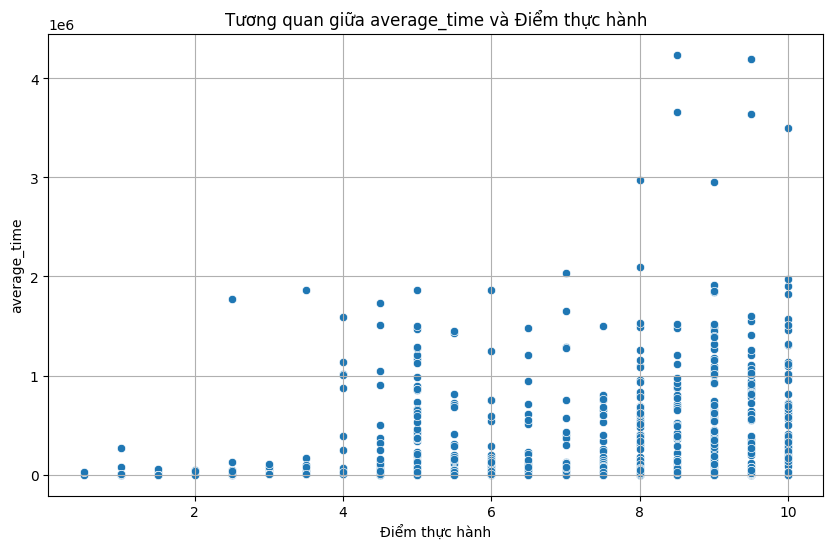

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, y='average_time', x='TH')

plt.title('Tương quan giữa average_time và Điểm thực hành')
plt.ylabel('average_time')
plt.xlabel('Điểm thực hành')
plt.grid(True)
plt.show()

In [47]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   hash                        753 non-null    object 
 1   TH                          753 non-null    float64
 2   submit_count                753 non-null    int64  
 3   final_submit_count          753 non-null    int64  
 4   avg_final_score             753 non-null    float64
 5   count_status_0              753 non-null    int64  
 6   count_status_1              753 non-null    int64  
 7   count_status_2              753 non-null    int64  
 8   count_status_3              753 non-null    int64  
 9   lang_count                  753 non-null    int64  
 10  avg_late_coef               753 non-null    float64
 11  avg_submission_per_problem  753 non-null    float64
 12  average_time                753 non-null    int64  
dtypes: float64(4), int64(8), object(1)


In [48]:
df_train.to_csv('df_train_model4_1.csv', index=False)